# Incremental Capstone 12 - Deep Learning with TensorFlow and Keras

## Problem Scenario

Advance deep learning and data engineering expertise through projects that apply neural networks and data processing techniques to real-world problems. This includes developing autoencoders for medical image denoising. These projects emphasize model design, data handling, and evaluation to strengthen technical proficiency in supervised and unsupervised learning.

### Problem Objective 

Develop deep learning models 

## Notebook Setup

### Imports

In [41]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, GRU, Dropout, Bidirectional, SpatialDropout2D, Conv2D, MaxPooling2D, GlobalMaxPooling1D, Input, Conv2DTranspose
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.regularizers import l2

### Configuration

In [19]:
# Configure GPU settings
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Use only GPU 0
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpus[0], True)

        print(f'Using GPU: {gpus[0]}')
        print('Memory growth enabled')

    except RuntimeError as e:
        print(e)

In [20]:
pd.set_option("display.max_columns", None)

## 1. EDA

### 1.1 Load

In [4]:
# DATASET_URL = ("https://github.com/gperdrizet/FSA_devops/blob/main/data/unit4/DENTAL_1.NPZ")

# os.makedirs("./data", exist_ok=True)

# # Download the file from the URL
# response = requests.get(DATASET_URL)
# if response.status_code == 200:
#     with open("./data/DENTAL_1.NPZ", "wb") as f:
#         f.write(response.content)
#     print(f"file saved to ./data")
# else:
#     print(f"Failed to download file. Status Code: {response.status_code}")

In [5]:
data = np.load("./data/DENTAL_1.NPZ")
data.files

['x_train', 'y_train', 'x_test', 'y_test']

In [6]:
X_train = data["x_train"]
y_train = data['y_train']
X_test = data['x_test']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (92, 256, 256, 3)
y_train shape: (92,)
X_test shape: (24, 256, 256, 3)
y_test shape: (24,)


Looking at the shapes of our data we can conclude these images are RGB images we are working with. Why is that the case? Aren't X-Rays grayscale in the real world? Let's check this.

## 2. Preprocess

### 2.1 Image Characteristics
- Check pixel ranges
- Check dtypes
- Add noise
- View images

In [7]:
#Check how large our image pixel ranges are 
print(f"X_train Pixel ranges: {X_train.min()}, {X_train.max()}")
print(f"y_train Pixel ranges: {y_train.min()}, {y_train.max()}")
print(f"X_test Pixel ranges: {X_test.min()}, {X_test.max()}")
print(f"y_test Pixel ranges: {y_test.min()}, {y_test.max()}")

X_train Pixel ranges: 0.0, 1.0
y_train Pixel ranges: 0, 0
X_test Pixel ranges: 0.0, 1.0
y_test Pixel ranges: 0, 0


Evaluating our range of pixels we can conclude our images are already normalized, this is good we can skip this step. Now, let's check our data to be actually on a grayscale.

In [8]:
#Check if our channels are identical to ensure these are actually grayscale (we are asking is R=G=B? If yes, then it is grayscale)
np.allclose(X_train[0, :, :, 0], X_train[0, :, :, 1])
np.allclose(X_train[0, :, :, 1], X_train[0, :, :, 2])

True

Upon finding out our data is grayscale we can safely and confidently convert it now into 1 channel for efficiency.

In [9]:
#Convert to single channel for grayscale efficiency for our model, TensorFlow prefers a "channel-last format so we convert the last parameter"
X_train = X_train[..., 0:1] #Using 0:1 keeps channel dimension
X_test = X_test[..., 0:1]

print(f"Single channel shape of X_train: {X_train.shape}")

Single channel shape of X_train: (92, 256, 256, 1)


In [10]:
#Check our dtype
X_train.dtype

dtype('float64')

Seeing as our dtype is bigger than TensorFlow and GPU computational restrictions we can reduce the precision needed. On data that is a range of 0-1 sized pixels, of size 256x256 images, this is safe and practical to save model performance and GPU memory later on for training.

In [11]:
#Convert our data now ahead of time to match the already default Tensorflow DNN weights to better memory usage and performance
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

print(X_train.dtype)

float32


In [12]:
# Add Gaussian Noise Injection all over our image data
sigma = 0.1 #Moderate Noise level

def add_gaussian_noise(images, sigma):
    noise = tf.random.normal(
        shape=tf.shape(images),
        mean=0.0,
        stddev=sigma,
        dtype=tf.float32
    )
    
    noisy_images = images + noise
    noisy_images = tf.clip_by_value(noisy_images, 0.0, 1.0) #Clip to keep consistent ranges
    
    return noisy_images

X_train_noisy = add_gaussian_noise(X_train, sigma)
X_test_noisy = add_gaussian_noise(X_test, sigma)

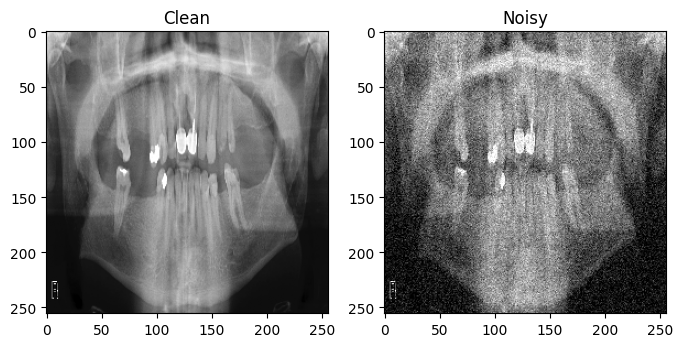

In [73]:
#Visualize our clean vs noisy data 
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(np.squeeze(X_train[0]), cmap='gray')
plt.title("Clean")

plt.subplot(1,2,2)
plt.imshow(np.squeeze(X_train_noisy[0]), cmap='gray')
plt.title("Noisy")

plt.show()


Sanity Checking by visualizing our noisy data we created. We can clearly see above, the blurry botches of data inserted into our first image as a test. This function will help later for training when we can customize or use it in randomization during batches of training.

### 2.2 Quantify Image Differences 

In [ ]:
# Measure MSE(Mean Squared Error) Metric
mse = tf.reduce_mean(tf.square(X_train - X_train_noisy))
print(f"MSE: {mse}")


MSE: 0.009396684356033802


**INTERPRETATION**: This helps us determine pixel errors where lower = better

In [ ]:
# Measure PSNR(Peak Signal-to-Noise Ratio) Metric
psnr =  tf.image.psnr(X_train, X_train_noisy, max_val=1.0)
print(f"Average PSNR dB: {tf.reduce_mean(psnr)}")

Average PSNR dB: 20.272571563720703


**INTERPRETATION**: Since our images are normalized we want max_val=1. A higher PSNR = better quality images

Expected range:
- 30–40 dB → light noise
- 20–30 dB → moderate noise
- <20 dB → heavy degradation

In [27]:
#Measure SSIM(Structural Similarity Index) Metric
ssim = tf.image.ssim(X_train, X_train_noisy, max_val=1.0) #Max same as before
print(f"Average SSIM: {tf.reduce_mean(ssim)}")

Average SSIM: 0.29089561104774475


**INTERPRETATION**: SSIM tries to measure luminence, contrast and structural similarities.

Range:
- 1.0 being identical
- 0 being completely different

Expected range:
- 0.95+ → very mild noise
- 0.80–0.95 → moderate
- <0.75 → strong distortion

**NOTE**: SSIM is argueably the most important since we want to ensure we understand the edges and bone measurements of X-rays similarities and differences when looking at these images.

Since we want to train a model to learn, PSNR being close to or reflecting heavy degradation is perfect for our model! If we only created a light noise or higher than 40dB noise then we wouldn't have a good training sample. Same goes for SSIM, we are reaching a very small value from our range at 0.29 so this is good in our case! We want the pictures to not reflect each other so the model can figure it our later for training. It leaves us enough to work with, without the model just random guessing.

## 3. Design Autoencoder

We are working with:
- input shape(256, 256, 1)
- 92 images
- Normalized 0-1
- Gaussian Noise


In [49]:
# Model Hyperparameters
dropout = 0.2
hidden_dim = 32 #initial filter size
padding = "same"
output_dim = 1 #Output filter size
l2_reg = 0.001      #L2 regularization strength
learning_rate = 0.001       #LR for fine-tuning

# Create our encoder to reduce size 256 -> 128 -> 64
model = Sequential([
    Input((256, 256, 1)),
    SpatialDropout2D(dropout),

    #Encoder layers
    Conv2D(hidden_dim, kernel_size=3, strides=2, activation="relu", padding=padding),   #Using strides in-place of maxpooling2d to see how it works instead
    Conv2D(hidden_dim * 2, kernel_size=3, strides=2, activation="relu", padding=padding),
    Conv2D(hidden_dim * 4, kernel_size=3, activation="relu", padding=padding),

    #Decoder
    Conv2DTranspose(hidden_dim * 2, kernel_size=3, strides=2, activation="relu", padding=padding),
    Conv2DTranspose(hidden_dim, kernel_size=3, strides=2, activation="relu", padding=padding),

    #Output
    Dropout(dropout),
    Conv2D(output_dim, kernel_size=3, activation="sigmoid", padding=padding, kernel_regularizer=l2(l2_reg))
])

model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mse']
)

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spatial_dropout2d_4             │ (None, 256, 256, 1)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_26             │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_27             │ (None, 256, 256, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 256, 256, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

We are using Conv2D because it can extract edges, gradients and textures better. Using strides will compress our spatial information which is needed for the nature of our autoencoder. Conv2DTranspose will learn upsampling from our compressed data. We use sigmoid activation because our data is normalized between 0-1. MSE for our loss metric because it directly penalizes pixel errors during training, instead of looking at SSIM which can be unstable and converge slower because it is more complex gradient. We can later evaluate on this metric. 

**IMPORTANT**: We keep our output as a Conv2D because this is an Image Autoencoder as a Fully Convolutional Network and we don't want to compress and flatten our data. 

## 4. Baseline Training

### 4.1 Training Callbacks 

In [50]:
callbacks = [
    ModelCheckpoint(
        './models/cae_dentals.keras',
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    TensorBoard(
        log_dir='./logs/cae_dentals',
        histogram_freq=1,
        write_graph=True
    )
]

### 4.2 Train the model

In [51]:
history = model.fit(
    X_train_noisy,  # Noisy Input
    X_train,        # Clean Target
    validation_data=(X_test_noisy, X_test),
    epochs=20,
    batch_size=8,   # Only 92 images, keep batches small 92/10 = 9.2
    callbacks=callbacks
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - loss: 0.0543 - mse: 0.0525
Epoch 1: val_loss improved from None to 0.04582, saving model to ./models/cae_dentals.keras

Epoch 1: finished saving model to ./models/cae_dentals.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - loss: 0.0529 - mse: 0.0512 - val_loss: 0.0458 - val_mse: 0.0443
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 0.0385 - mse: 0.0370
Epoch 2: val_loss improved from 0.04582 to 0.01564, saving model to ./models/cae_dentals.keras

Epoch 2: finished saving model to ./models/cae_dentals.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - loss: 0.0333 - mse: 0.0318 - val_loss: 0.0156 - val_mse: 0.0141
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - loss: 0.0271 - mse: 0.0256
Epoch 3: val_loss did not improve from 0.01564
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 416ms/step - loss: 0.0223 - mse: 0.0208 - val_loss: 0.0229 - val_mse: 0.0214
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.0205 - mse: 0.01

### 4.3 Evaluation

Evaluate our model after the model predicts and denoises our data compare to the original noisy images we created earlier.

In [55]:
#Load best model for predict
model = tf.keras.models.load_model('./models/cae_dentals.keras')

#Have the model denoise our data 
X_test_denoised = model.predict(X_test_noisy)

#Calculate MSE after
mse_after = tf.reduce_mean(tf.square(X_test - X_test_denoised))

#Calculate PSNR after
psnr_after = tf.image.psnr(X_test, X_test_denoised, max_val=1.0)

#Calculate SSIM after(most important, we want a similar image)
ssim_after = tf.image.ssim(X_test, X_test_denoised, max_val=1.0)

print(f"MSE Before: {mse}, MSE After: {mse_after}")
print(f"PSNR Before: {tf.reduce_mean(psnr)}, PSNR After: {tf.reduce_mean(psnr_after)}")
print(f"SSIM Before: {tf.reduce_mean(ssim)}, SSIM After: {tf.reduce_mean(ssim_after)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
MSE Before: 0.009396684356033802, MSE After: 0.004915444180369377
PSNR Before: 20.272571563720703, PSNR After: 23.153776168823242
SSIM Before: 0.29089561104774475, SSIM After: 0.697182834148407


Looking at our evaluation results we got:
- MSE got a 48% smaller, going lower is an improvement
- PSNR went up +2.88 dB, going up is an improvement
- SSIM went up +0.41 which is 2.396 times bigger, bigger values means more identical

### 4.4 MSE Before and After

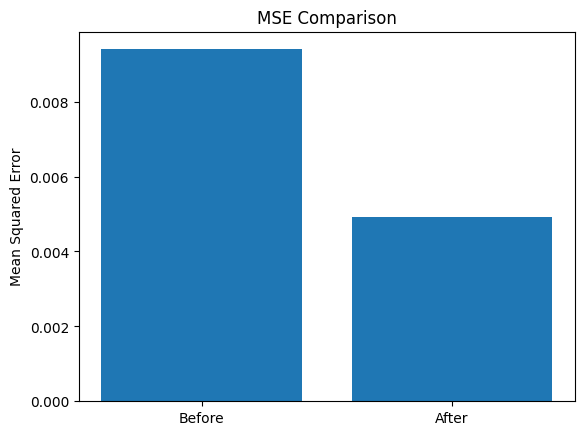

In [56]:
#Plot MSE before and after bar plot
plt.bar(['Before', 'After'], [mse, mse_after])
plt.title('MSE Comparison')
plt.ylabel('Mean Squared Error')
plt.show()


### 4.5 PSNR Before and After 

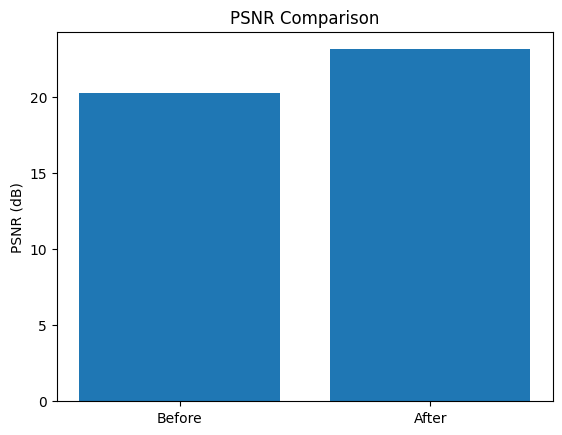

In [59]:
#Plot PSNR before and after bar plot
plt.bar(['Before', 'After'], [tf.reduce_mean(psnr), tf.reduce_mean(psnr_after)])
plt.title('PSNR Comparison')
plt.ylabel('PSNR (dB)')
plt.show()

### 4.6 SSIM Before and After

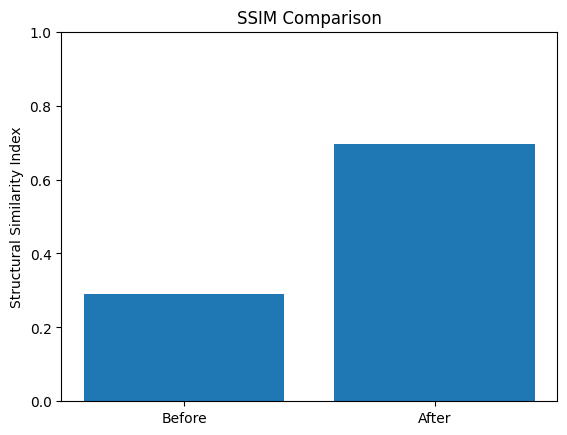

In [60]:
#Plot SSIM before and after bar plot
plt.bar(['Before', 'After'], [tf.reduce_mean(ssim), tf.reduce_mean(ssim_after)])
plt.title('SSIM Comparison')
plt.ylabel('Structural Similarity Index')
plt.ylim(0, 1)
plt.show()


### 4.7 Images Comparison

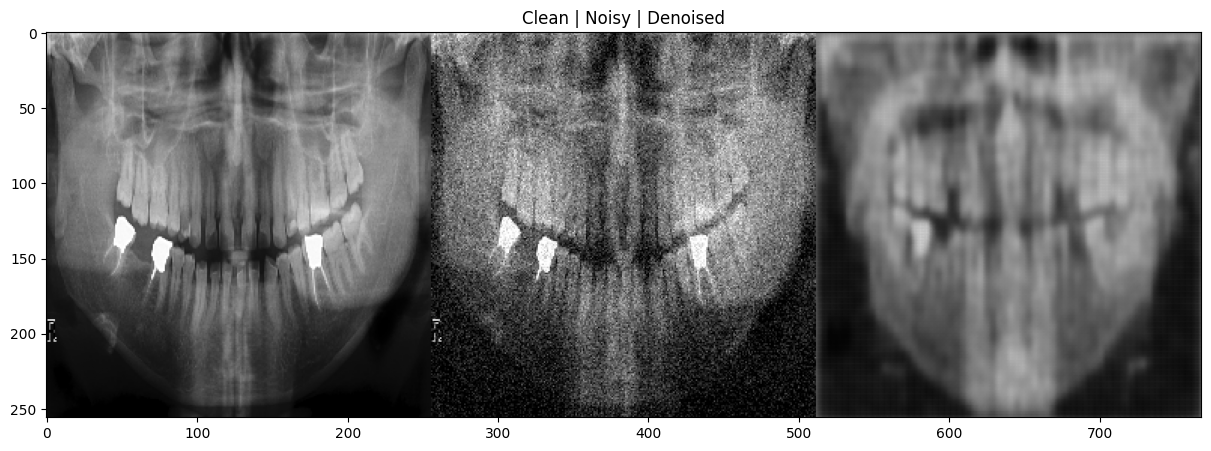

In [74]:
#Visualize clean vs noisy vs denoised images

# Choose image index
idx = 7  # change if you want to inspect a different image

clean_img = np.squeeze(X_train[idx])
noisy_img = np.squeeze(X_train_noisy[idx])
denoised_img = np.squeeze(X_test_denoised[idx])

# Concatenate images horizontally
comparison = np.concatenate((clean_img, noisy_img, denoised_img), axis=1)

# Single plot (no subplots)
plt.figure(figsize=(15, 5))
plt.imshow(comparison, cmap='gray')
plt.title("Clean | Noisy | Denoised")
plt.show()


## 5. Discussion

### 5.1 Preprocessing
During preprocessing we discovered that images were already normalized by getting our min and max limits of our pixel values. From the shape of our images we discovered it was stored as RGB values. We followed this by asking the question, aren't X-rays are usually grayscale? We checked this and confirmed the R G and B scales were similar, this let us cut the channels down to 1 channel. We learned that TensorFlow limits and calculates at maximum of float32 so we checked our dtypes and found we were above this. We scaled this down for efficiency and speed. We added Gaussian noise and visualized our images to get a better understanding.

### 5.2 Model Design
We learned our Fully Convolutional Model will learn structure not just pixels, we learned that SSIM helps us measure luminence, contrast and structural similarities. This metric is the most important in terms of understanding and showing structure in our case of dental images. The model is very simple and few parameters but we increased our structure of these images by over 200% from our noisy image. 

### 5.3 Training
Our training resulted in an early stopping at epoch 15 and avoiding overfitting. We got better results overall on all metrics MSE, PSNR, and SSIM. We learned this increase is huge even given a small basic model without using U-net or Optuna. We followed by looking at images from original, noisy and denoised results for visual interpretation. We can push this model further with Optuna, data augmentation, U-net, SSIM-based hybrid loss. 